In [1]:
import pandas as pd
df = pd.read_csv('amazon_specs_combined.csv')

In [2]:
df.head()

,category,subtype,market_tier,condition,is_premium_brand,tech_generation,brand,confidence,printer_tech,is_color,...,is_original,connector_gender,is_wireless,port_count,storage_type,pd_wattage,model_used,original_title,original_row_id,error_log
0,PC Components (Core),ssd_internal,Mainstream,New,False,Current-Gen,OWC,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NVMe,NaN,gpt-4o-mini,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,0.0,NaN
1,PC Components (Core),ssd_internal,Mainstream,New,True,Current-Gen,OWC,0.95,NaN,NaN,...,NaN,NaN,NaN,NaN,SSD,NaN,gpt-4o-mini,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,1.0,NaN
2,"Office, Printing & Power",toner_ink,Mainstream,New,True,Current-Gen,HP,0.95,Inkjet,False,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,HP 67XL Black High-yield Ink Cartridge | Works...,2.0,NaN
3,"Office, Printing & Power",toner_ink,Mainstream,New,False,Current-Gen,HP,0.95,Inkjet,True,...,NaN,NaN,NaN,NaN,NaN,NaN,gpt-4o-mini,HP 67 Black/Tri-color Ink Cartridges for HP Pr...,3.0,NaN
4,Audio & Media Systems,headphones,Mainstream,New,False,Current-Gen,Sony,0.95,NaN,True,...,NaN,NaN,False,NaN,NaN,NaN,gpt-4o-mini,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.0,NaN


C:\Users\USER\AppData\Local\Temp\ipykernel_22256\2487866918.py:27: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\anaconda3\envs\TFM\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


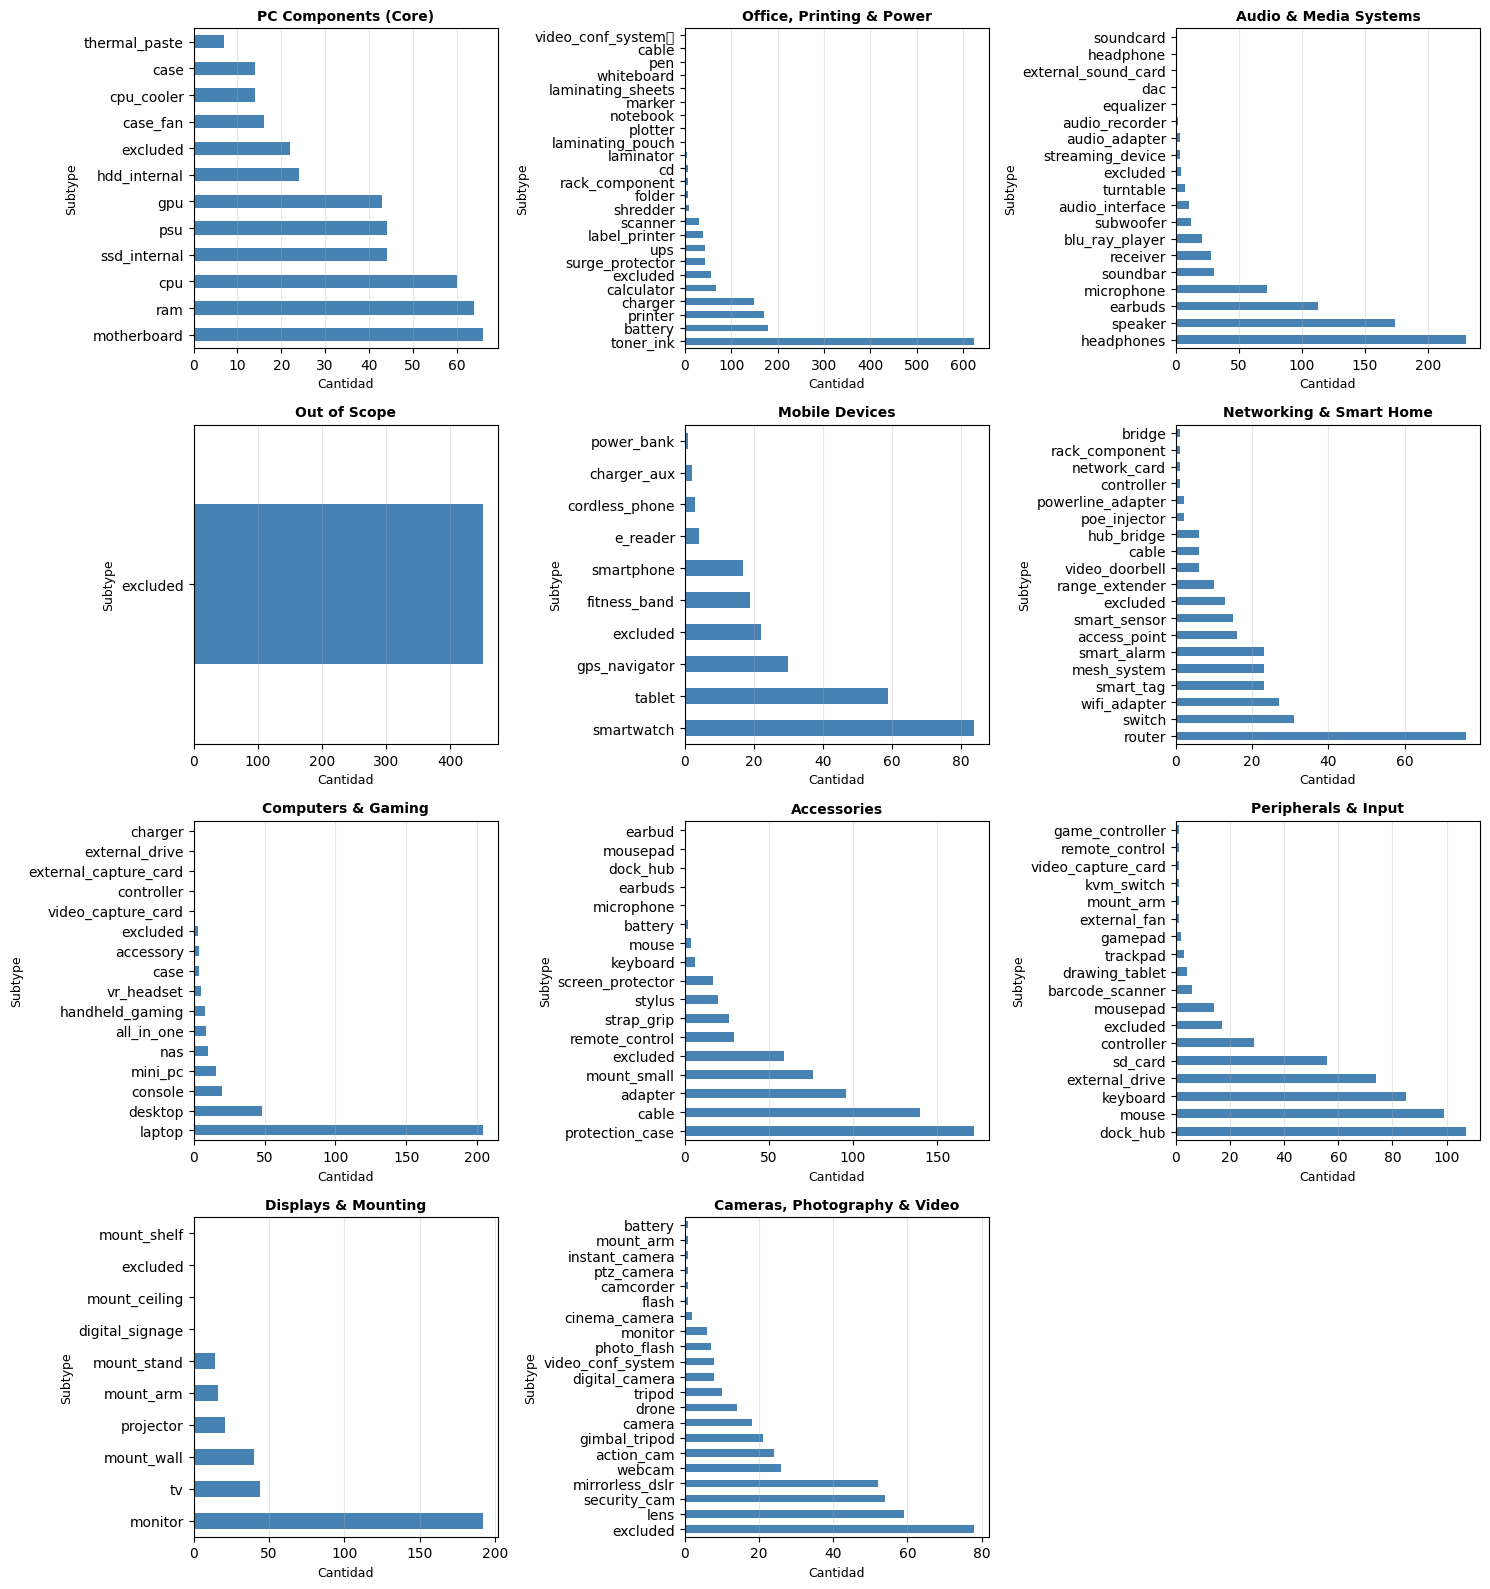

In [3]:
import matplotlib.pyplot as plt

# Obtener todas las categorías únicas
categorias = df['category'].unique()

# Crear un dashboard con subplots en grid de 3 columnas
num_cols = 3
num_rows = (len(categorias) + num_cols - 1) // num_cols  # Redondea hacia arriba

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 4*num_rows))
axes = axes.flatten()  # Convierte a array 1D para iterar fácilmente

# Iterar sobre cada categoría y crear una gráfica
for idx, categoria in enumerate(categorias):
    subtype_counts = df[df['category'] == categoria]['subtype'].value_counts()
    
    subtype_counts.plot(kind='barh', ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'{categoria}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Cantidad', fontsize=9)
    axes[idx].set_ylabel('Subtype', fontsize=9)
    axes[idx].grid(axis='x', alpha=0.3)

# Ocultar los subplots vacíos
for idx in range(len(categorias), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
df[df['category'] == 'Office, Printing & Power'].subtype.value_counts()

subtype
toner_ink              624
battery                179
printer                170
charger                150
calculator              67
excluded                56
surge_protector         44
ups                     43
label_printer           39
scanner                 30
shredder                 9
folder                   7
rack_component           7
cd                       6
laminator                4
laminating_pouch         2
plotter                  2
notebook                 1
marker                   1
laminating_sheets        1
whiteboard               1
pen                      1
cable                    1
video_conf_system\t      1
Name: count, dtype: int64

In [11]:
df_final.head()

,category,subtype,market_tier,condition,is_premium_brand,tech_generation,brand,confidence,printer_tech,is_color,...,badge_best_seller,badge_ends_in,badge_limited_time_deal,badge_no_badge,badge_save_xpct,product_category,log_purchased_last_month,log_original_price,log_total_reviews,price_real
0,PC Components (Core),ssd_internal,Mainstream,New,False,Current-Gen,OWC,0.95,NaN,NaN,...,0,0,0,1,0,PC Components,0.000000,5.484755,5.883322,239.99
1,PC Components (Core),ssd_internal,Mainstream,New,True,Current-Gen,OWC,0.95,NaN,NaN,...,0,0,0,1,0,Storage & Memory Cards,0.000000,3.783962,5.624018,42.99
2,"Office, Printing & Power",toner_ink,Mainstream,New,True,Current-Gen,HP,0.95,Inkjet,False,...,1,0,0,0,0,"Office Supplies, Ink & Toner",10.819798,3.607941,11.523598,35.89
3,"Office, Printing & Power",toner_ink,Mainstream,New,False,Current-Gen,HP,0.95,Inkjet,True,...,0,0,0,1,0,"Office Supplies, Ink & Toner",10.819798,3.804215,10.986868,43.89
4,Audio & Media Systems,headphones,Mainstream,New,False,Current-Gen,Sony,0.95,NaN,True,...,1,0,0,0,0,"Audio, Sound & Recording Gear",9.210440,2.355178,11.598433,9.54


In [14]:
import pandas as pd
import numpy as np


# 1. Carga tus datos (ajusta los nombres de tus archivos)
df_specs = pd.read_csv('amazon_specs_combined.csv')
df_prices = pd.read_csv('../../Datasets/amazon_final.csv')

# 2. Une ambos datasets (usando el ID o el Título como llave)
df_final = pd.merge(
    df_specs, 
    df_prices, 
    left_on='original_title', 
    right_on='product_title'
)

# 3. Revertir el log1 para ver el precio real
# Si usaste log natural (ln(1+x)):
df_final['price_real'] = np.exp(df_final['log_original_price']) - 1

# Si usaste log base 10 (log10(1+x)):
# df['price_real'] = (10 ** df['log1_price']) - 1
subset = df_final[df_final['category'] == 'Office, Printing & Power']
subtype_counts = subset['subtype'].value_counts()
rare_subtypes = subtype_counts[subtype_counts < 50].index
expensive_accessories = subset[subset['subtype'].isin(rare_subtypes)].sort_values(by='subtype', ascending=False).iloc[0:700]
# 5. Mostrar el Top 20
print("AUDITORÍA DE ACCESORIOS CAROS:")

# 1. Definimos una función que envuelve la URL en una etiqueta HTML <img>
def render_image(url):
    return f'<img src="{url}" width="80" >'

# 2. Seleccionamos la muestra
sample_peripherals = expensive_accessories[['original_title', 'subtype', 'price_real', 'product_image_url']]

# 3. Mostramos la tabla renderizando el HTML
# 'escape=False' permite que el navegador lea los tags <img> en lugar de verlos como texto
HTML(sample_peripherals.to_html(escape=False, formatters=dict(product_image_url=render_image)))

AUDITORÍA DE ACCESORIOS CAROS:


,original_title,subtype,price_real,product_image_url
1275,"Quartet Whiteboard, Glass Dry Erase Board, Magnetic, 6' x 4', Infinity Frameless Mounting, White Surface, Accessory Tray, 1 Dry Erase Marker and 2 Glass Board Magnets (G7248W)",whiteboard,399.00,
2461,"Eneloop Panasonic BK-3MCCA4BA AA 2100 Cycle Ni-MH Pre-Charged Rechargeable Batteries, 4-Battery Pack",video_conf_system\t,14.90,
2617,"Intermatic T104 24-Hour Mechanical Timer Switch - 208–277 VAC, DPST, Indoor Metal Enclosure, Heavy-Duty, Manual Override, 40 Amp - Ideal for Lights, Pumps, Fans, and HVAC Systems",ups,84.69,
4033,"CyberPower ST900U Standby UPS System, 900VA/500W, 12 Outlets, 2 USB Charging Ports, Compact, Black",ups,119.95,
3805,CyberPower RMCARD205 UPS & ATS PDU Remote Management Card,ups,340.95,
3766,"CyberPower RB1290X2 UPS Replacement Battery Cartridge, Maintenance-Free, User Installable, 12V/9Ah",ups,100.14,
3697,"Tripp Lite OMNI1500LCDT 1500VA UPS Battery Back Up AVR LCD Display 10 Outlets 120V 810W Tel & Coax Protection USB, 3 Year Warranty & $250,000 Insurance, Black",ups,276.75,
991,"CyberPower OR500LCDRM1U Smart App LCD UPS Battery Backup and Surge Protector, 500VA/300W, 6 Outlets, AVR, 1U Rackmount, UL Certified",ups,219.95,
2051,"Tripp Lite 12-Outlet Rack Mount Power Strip PDU, Six Front & Six Rear Facing Outlets, 15A, 120V, 15ft Cord with Right-Angle Plug, Horizontal 1U Rack Mount, Lifetime Manufacturer's Warranty (RS1215-RA)",ups,109.60,
3609,Furman M-8x2 Merit Series 8 Outlet Power Conditioner & Surge Protector with (2) Hosa 18 Gauge Electrical Extension Cable,ups,115.95,
